In [ ]:
# Task 2: Customer Segmentation Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import zipfile
import os

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/customer_data")

print("Dataset extracted successfully!")
print(os.listdir("/content/customer_data"))

Dataset extracted successfully!
['Online Retail Analysis.pdf', 'customer_summary copy.csv', 'retail_cleaned.csv', 'retail_segmented.csv', 'monthly_sales copy.csv']


In [ ]:
print("Files inside the extracted folder:")

for file in os.listdir("/content/customer_data"):
    print(file)

Files inside the extracted folder:
Online Retail Analysis.pdf
customer_summary copy.csv
retail_cleaned.csv
retail_segmented.csv
monthly_sales copy.csv


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/customer_data/customer_summary copy.csv
/content/customer_data/retail_cleaned.csv
/content/customer_data/retail_segmented.csv
/content/customer_data/monthly_sales copy.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv


In [ ]:
# Load customer-level dataset

df = pd.read_csv("/content/customer_data/customer_summary copy.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (4339, 6)

Columns:
['CustomerID', 'total_orders', 'total_quantity', 'total_spent', 'last_purchase', 'first_purchase']

First 5 rows:


,CustomerID,total_orders,total_quantity,total_spent,last_purchase,first_purchase
0,12346.0,1,74215,77183.60,2011-1-18 10:01:00,2011-1-18 10:01:00
1,12347.0,7,2458,4310.00,2011-12-7 15:52:00,2010-12-7 14:57:00
2,12348.0,4,2341,1797.24,2011-9-25 13:13:00,2010-12-16 19:09:00
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00
4,12350.0,1,197,334.40,2011-2-2 16:01:00,2011-2-2 16:01:00


In [ ]:
# Initial inspection of the customer dataset

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(4339, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4339 entries, 0 to 4338
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      4338 non-null   float64
 1   total_orders    4339 non-null   int64  
 2   total_quantity  4339 non-null   int64  
 3   total_spent     4339 non-null   float64
 4   last_purchase   4339 non-null   object 
 5   first_purchase  4339 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 203.5+ KB

Missing Values:
CustomerID        1
total_orders      0
total_quantity    0
total_spent       0
last_purchase     0
first_purchase    0
dtype: int64

Duplicate Rows:
0


In [ ]:
# Descriptive statistics

print("Column Names:")
print(df.columns.tolist())

print("\nDescriptive Statistics:")
display(df.describe(include="all"))

Column Names:
['CustomerID', 'total_orders', 'total_quantity', 'total_spent', 'last_purchase', 'first_purchase']

Descriptive Statistics:


,CustomerID,total_orders,total_quantity,total_spent,last_purchase,first_purchase
count,4338.000000,4339.000000,4339.000000,4.339000e+03,4339,4339
unique,NaN,NaN,NaN,NaN,4200,4241
top,NaN,NaN,NaN,NaN,2011-12-1 15:12:00,2010-12-7 15:48:00
freq,NaN,NaN,NaN,NaN,3,3
mean,15300.408022,4.600138,1287.941000,2.458328e+03,NaN,NaN
std,1721.808492,22.943499,8123.438301,2.809265e+04,NaN,NaN
min,12346.000000,1.000000,1.000000,3.750000e+00,NaN,NaN
25%,13813.250000,1.000000,160.000000,3.074300e+02,NaN,NaN
50%,15299.500000,2.000000,379.000000,6.745200e+02,NaN,NaN
75%,16778.750000,5.000000,993.000000,1.662060e+03,NaN,NaN


In [ ]:
# Prepare features for customer segmentation

features = ['total_orders', 'total_quantity', 'total_spent']

# Remove rows with missing values in selected features
segmentation_data = df[features].dropna().copy()

print("Selected Behavioural Features:")
print(features)

print("\nSegmentation Dataset Shape:")
print(segmentation_data.shape)

print("\nMissing Values:")
print(segmentation_data.isnull().sum())

display(segmentation_data.head())

Selected Behavioural Features:
['total_orders', 'total_quantity', 'total_spent']

Segmentation Dataset Shape:
(4339, 3)

Missing Values:
total_orders      0
total_quantity    0
total_spent       0
dtype: int64


,total_orders,total_quantity,total_spent
0,1,74215,77183.60
1,7,2458,4310.00
2,4,2341,1797.24
3,1,631,1757.55
4,1,197,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the selected features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(segmentation_data)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features
)

print("Features standardized successfully!")

display(scaled_df.head())

Features standardized successfully!


,total_orders,total_quantity,total_spent
0,-0.156931,8.978398,2.660264
1,0.104611,0.144052,0.065921
2,-0.026160,0.129647,-0.023535
3,-0.156931,-0.080879,-0.024948
4,-0.156931,-0.134311,-0.075613


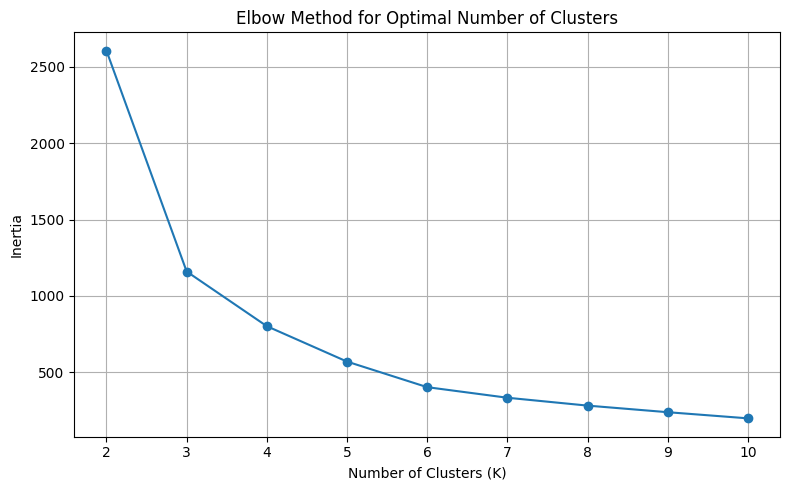

In [ ]:
from sklearn.cluster import KMeans

# Elbow Method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The Elbow Method is used to identify a suitable number of customer
segments. The optimal K is selected at the point where the reduction
in inertia begins to slow down significantly.

In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit the model and predict clusters
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the original dataset
df['Cluster'] = clusters

# Display the first few rows
df.head()

,CustomerID,total_orders,total_quantity,total_spent,last_purchase,first_purchase,Cluster
0,12346.0,1,74215,77183.60,2011-1-18 10:01:00,2011-1-18 10:01:00,3
1,12347.0,7,2458,4310.00,2011-12-7 15:52:00,2010-12-7 14:57:00,0
2,12348.0,4,2341,1797.24,2011-9-25 13:13:00,2010-12-16 19:09:00,0
3,12349.0,1,631,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,0
4,12350.0,1,197,334.40,2011-2-2 16:01:00,2011-2-2 16:01:00,0


Observation

Observation: K-Means clustering successfully grouped the customers into 5 distinct clusters based on their selected features. Each customer is assigned a cluster label representing their customer segment.

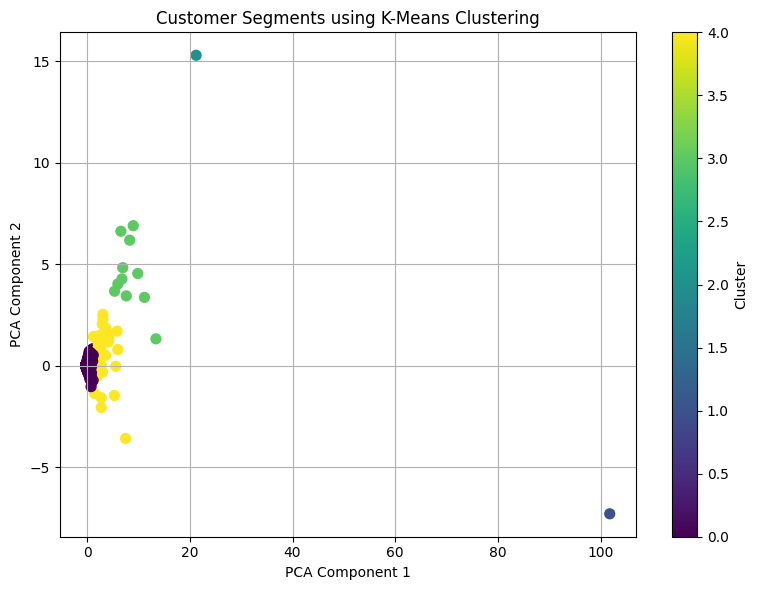

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce the scaled features to 2 dimensions
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(
    pca_features,
    columns=['PCA1', 'PCA2']
)

# Add cluster labels
pca_df['Cluster'] = df['Cluster']

# Plot the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PCA1'],
    pca_df['PCA2'],
    c=pca_df['Cluster'],
    cmap='viridis',
    s=50
)

plt.title("Customer Segments using K-Means Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

Observation

Observation: The PCA visualization shows the distribution of customers across different clusters. Customers within the same cluster have similar characteristics based on the selected features, while customers in different clusters show distinct patterns.

In [ ]:
# Create DataFrame from scaled features
scaled_df = pd.DataFrame(
    scaled_features,
    columns=features
)

# Add cluster labels
scaled_df['Cluster'] = df['Cluster'].values

# Calculate mean values for each cluster
cluster_analysis = scaled_df.groupby('Cluster').mean()

# Display cluster analysis
cluster_analysis

,total_orders,total_quantity,total_spent
Cluster,,,
0,-0.037531,-0.059429,-0.038235
1,62.046504,51.619076,62.401382
2,2.981574,24.084581,9.887984
3,1.935406,8.138386,4.314872
4,1.690705,2.028376,0.999346


Observation

Observation: The cluster analysis provides the average characteristics of customers in each segment. These values can be compared to understand the differences between customer groups and identify high-value, low-value, and other behavioral segments.

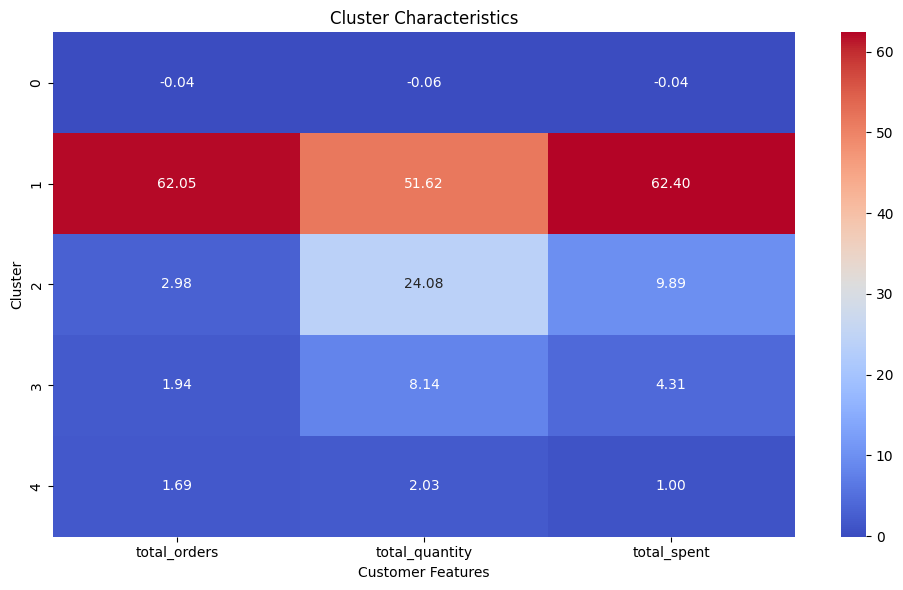

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_analysis,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Cluster Characteristics")
plt.xlabel("Customer Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

Observation

Observation: The heatmap highlights the differences in customer characteristics across the clusters. Higher and lower values indicate the features that distinguish one customer segment from another. This helps in understanding the behavior and value of each customer group.

In [ ]:
# Add cluster labels to the original dataset
df['Cluster'] = clusters

# Calculate average values for each cluster
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

# Display cluster profiles
cluster_profile

,CustomerID,total_orders,total_quantity,total_spent
Cluster,,,,
0,15302.659038,3.739141,805.229799,1.384316e+03
1,NaN,1428.000000,420564.000000,1.755277e+06
2,14646.000000,73.000000,196915.000000,2.802060e+05
3,15273.909091,49.000000,67392.000000,1.236606e+05
4,15102.840909,43.386364,17763.431818,3.052938e+04


Observation

Observation: The cluster profiles summarize the average characteristics of customers within each segment. These profiles help identify differences in customer age, income, spending behavior, and other numerical characteristics.

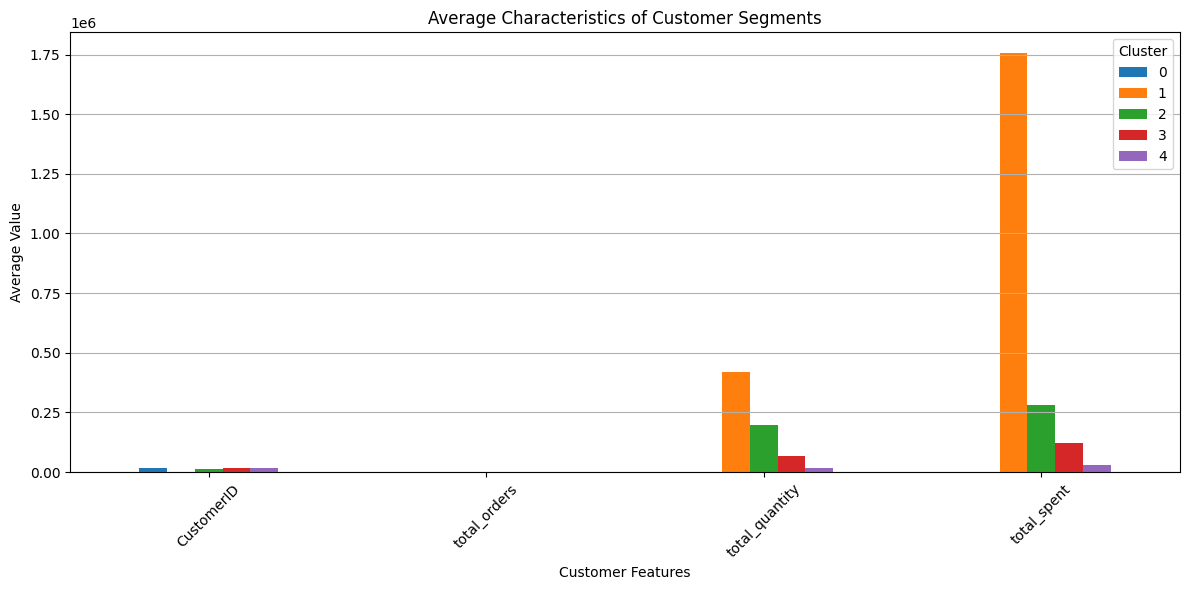

In [ ]:
import matplotlib.pyplot as plt

# Plot cluster profiles
cluster_profile.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Average Characteristics of Customer Segments")
plt.xlabel("Customer Features")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Observation

Observation: The bar chart compares the average characteristics of different customer segments. It clearly shows how customer groups differ in terms of their numerical features, making it easier to identify valuable and less active customer segments.

In [ ]:
# Display the cluster profiles
print("Customer Segment Summary:")
display(cluster_profile)

Customer Segment Summary:


,CustomerID,total_orders,total_quantity,total_spent
Cluster,,,,
0,15302.659038,3.739141,805.229799,1.384316e+03
1,NaN,1428.000000,420564.000000,1.755277e+06
2,14646.000000,73.000000,196915.000000,2.802060e+05
3,15273.909091,49.000000,67392.000000,1.236606e+05
4,15102.840909,43.386364,17763.431818,3.052938e+04


## Business Insights and Recommendations

Customer segmentation helps businesses understand different groups of customers based on their characteristics and spending behavior.

- **High-value customers:** Can be targeted with premium offers, loyalty rewards, and personalized promotions.
- **Potential customers:** Can be encouraged to increase their purchases through targeted discounts and product recommendations.
- **Regular customers:** Can be retained through personalized communication and loyalty programs.
- **Low-value customers:** Can be targeted with affordable offers and engagement campaigns.

These insights can help businesses improve customer retention, increase customer satisfaction, and develop more effective marketing strategies.